# VS-position GLM · binary angle/FIR basis

In [86]:
import json
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import nemos as nmo
import numpy as np
from scipy.io import loadmat


session_dir = Path("/mnt/senzailab/Kai/#Recording/m19/260827/260827_3")
data_dir = session_dir / "data"
kilosort_dir = session_dir / "kilosort/ProbeA/kilosort_3"
output_dir = data_dir / "glm"
unit_id = 243
bin_size = 0.02
angle_bin_size = 12
max_lag = 0.3
train_fraction = 0.8
regularizer_strength = 0.001
random_seed = 0


## 1. 读 mat file

In [87]:
session_info = json.loads((data_dir / "session_info.json").read_text())
session_name = Path(session_info["session_info"]["base_path"]).name
trials = loadmat(
    session_dir / f"{session_name}.mat", simplify_cells=True,
)["trials"]

spike_samples = np.load(kilosort_dir / "spike_times.npy")
spike_clusters = np.load(kilosort_dir / "spike_clusters.npy")
unit_info = np.genfromtxt(
    kilosort_dir / "cluster_KSLabel.tsv",
    delimiter="\t", names=True, dtype=None, encoding="utf-8",
)
unit_label = unit_info["KSLabel"][unit_info["cluster_id"] == unit_id][0]
unit_mask = spike_clusters == unit_id

on_list_times = np.load(data_dir / "on_list_times.npy")


## 4. 建立 VS info 和每个 white trial 的 onset impulse

In [88]:
vs_info = {
    "start": on_list_times[:-1],
    "end": on_list_times[1:],
    "position": np.array([trial["Square_PositionX"] for trial in trials]),
    "luminance": np.array([trial["Square_Luminance"] for trial in trials]),
}
bin_count = int((on_list_times[-1] - on_list_times[0]) / bin_size)
time_edges = on_list_times[0] + np.arange(bin_count + 1) * bin_size
time = time_edges[:-1] + bin_size / 2
trial_index = np.searchsorted(on_list_times, time, side="right") - 1
vs_position = vs_info["position"][trial_index] % 360
white_trial = vs_info["luminance"] == 1
white = white_trial[trial_index]

# 每一个 white trial 的起点都是 VS onset；不是只找 white block 的 0 -> 1。
onset_bin = np.searchsorted(
    time_edges, vs_info["start"][white_trial], side="right",
) - 1
onset_position = vs_info["position"][white_trial] % 360
onset = np.zeros(len(time), dtype=int)
onset[onset_bin] = 1


## 5. 建立 unit spike time 和每个 bin 的 spike count

In [89]:
# 已按 Kilosort 行顺序映射到 ADC clock；不要直接 samples / sample_rate。
adc_spike_times = np.load(data_dir / "probeA/adc_spike_time.npy")
unit_spike_times = adc_spike_times[unit_mask]
unit_spike_samples = spike_samples[unit_mask]
spike_counts = np.histogram(unit_spike_times, time_edges)[0]


## 6. NeMoS 基础：binary 角度 basis + binary FIR lag basis

In [90]:
# jax.config.update("jax_enable_x64", True)
angle_count = 360 // angle_bin_size
angle_edges = np.arange(angle_count + 1) * angle_bin_size
angle_centers = (angle_edges[:-1] + angle_edges[1:]) / 2
angle_basis = np.eye(angle_count)
lag_steps = np.arange(round(max_lag / bin_size) + 1)
lags = lag_steps * bin_size
lag_basis = np.eye(len(lags))

model = nmo.glm.GLM(
    observation_model=nmo.observation_models.PoissonObservations(),
    regularizer="Ridge",
    regularizer_strength=regularizer_strength,
    solver_name="LBFGS",
    solver_kwargs={"maxiter": 2000},
)


## 7. 建立 onset impulse × binary FIR design：11 lags × 15 positions

In [91]:
stimulus_onset = np.zeros((len(time), angle_count))
onset_angle = (onset_position // angle_bin_size).astype(int)
stimulus_onset[onset_bin, onset_angle] = 1

sample_index = np.arange(lag_steps[-1], len(time))
# 正 lag 只取过去的 onset；列按 lag 排列，每个 lag 内为 15 个角度。
design = np.column_stack([
    stimulus_onset[sample_index - lag] for lag in lag_steps
])
time = time[sample_index]
trial_index = trial_index[sample_index]
vs_position = vs_position[sample_index]
onset = onset[sample_index]
white = white[sample_index]
spike_counts = spike_counts[sample_index]

split_time = on_list_times[int(len(trials) * train_fraction)]
train = time < split_time
test = time >= split_time + max_lag
design.shape


(29979, 480)

## 8. 导入 data 到 GLM：fit -> predict -> 生成模拟 spikes

In [92]:
model.fit(design[train], spike_counts[train])
predicted_counts = np.asarray(model.predict(design))
firing_rate = predicted_counts / bin_size
generated_spike_counts = np.random.default_rng(random_seed).poisson(predicted_counts)


In [93]:
predicted_counts


array([0.0608242 , 0.06031541, 0.08554836, ..., 0.04918401, 0.05388636,
       0.05347754], shape=(29979,), dtype=float32)

## 9. GLM result save

In [94]:
output_dir.mkdir(exist_ok=True)
model.save_params(output_dir / f"{unit_id}_model.npz")
np.savetxt(
    output_dir / "vs_info.csv", np.column_stack(list(vs_info.values())),
    delimiter=",", header="start,end,position,luminance", comments="", fmt="%.18g",
)
np.savetxt(
    output_dir / f"{unit_id}_spikes.csv",
    np.column_stack([unit_spike_samples, unit_spike_times]),
    delimiter=",", header="spike_samples,spike_times", comments="", fmt=["%d", "%.18g"],
)
result = np.column_stack([
    time, trial_index, vs_position, onset, white, spike_counts, predicted_counts,
    firing_rate, generated_spike_counts, train, test,
])
np.savetxt(
    output_dir / f"{unit_id}.csv", result, delimiter=",", comments="", fmt="%.18g",
    header="time,trial_index,vs_position,onset,white,spike_counts,predicted_counts,"
           "firing_rate,generated_spike_counts,train,test",
)
design_labels = [
    f"vs_{angle}_lag_{lag}"
    for lag in np.rint(lags * 1000).astype(int) for angle in angle_edges[:-1]
]
np.savetxt(
    output_dir / f"{unit_id}_design.csv", design, delimiter=",", fmt="%d",
    header=",".join(design_labels), comments="",
)

# 输入和输出重建使用相同的 binary basis；拟合出的系数不是 0/1。
coefficients = np.asarray(model.coef_).reshape(len(lags), angle_count).T
rf = angle_basis @ coefficients @ lag_basis.T
np.savetxt(
    output_dir / f"{unit_id}_rf.csv",
    np.column_stack([np.repeat(angle_centers, len(lags)),
                     np.tile(lags, angle_count), rf.ravel()]),
    delimiter=",", header="vs_position,lag,coefficient", comments="", fmt="%.18g",
)


## 10. Plot GLM RF：VS angle × lag

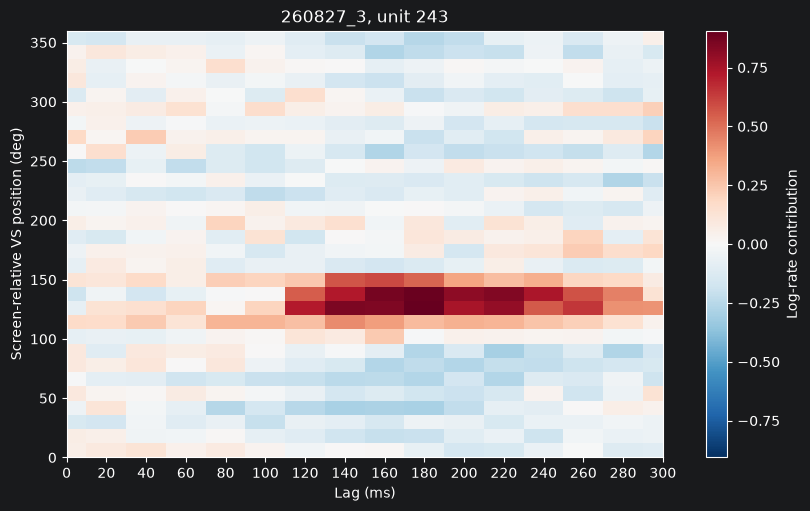

In [95]:
fig, axis = plt.subplots(figsize=(8, 5), layout="constrained")
limit = np.abs(rf).max()
plot = axis.pcolormesh(
    lags * 1000, angle_centers, rf,
    shading="nearest", cmap="RdBu_r", vmin=-limit, vmax=limit,
)
axis.set(
    xlabel="Lag (ms)", ylabel="Screen-relative VS position (deg)",
    xlim=(0, max_lag * 1000), ylim=(0, 360),
    xticks=lags * 1000, title=f"{session_dir.name}, unit {unit_id}",
)
fig.colorbar(plot, ax=axis, label="Log-rate contribution")
fig.savefig(output_dir / f"{unit_id}.png", dpi=160)
plt.show()


## 11. Summarize

In [96]:
baseline = spike_counts[train].mean()
gain = spike_counts[test] * np.log(predicted_counts[test] / baseline)
gain = (gain - predicted_counts[test] + baseline).sum()
gain /= spike_counts[test].sum() * np.log(2)
summary = (
    f"{session_dir.name}, unit {unit_id} ({unit_label})\n"
    f"Data: {session_dir}\n"
    f"Input: one impulse at each luminance=1 trial onset, labeled by VS position\n"
    f"Bins: {bin_size * 1000:g} ms, {angle_bin_size} deg; design: {design.shape}\n"
    f"Lags: {np.rint(lags * 1000).astype(int).tolist()} ms; positive lag uses past VS\n"
    f"Basis: binary onset-position one-hot and binary FIR\n"
    f"Response: Poisson spike counts on the full timeline\n"
    f"Train/test bins: {train.sum()} / {test.sum()}; train fraction: {train_fraction}\n"
    f"Test starts {max_lag * 1000:g} ms after the training boundary\n"
    f"Time reference: existing ADC-aligned trial and spike times\n"
    f"Simulation seed: {random_seed}\n"
    f"Ridge: {regularizer_strength}; "
    f"converged: {bool(model.solver_state_.stats.converged)}\n"
    f"Test recorded/predicted rate: {spike_counts[test].mean() / bin_size:.3f} / "
    f"{firing_rate[test].mean():.3f} Hz\n"
    f"Test gain vs constant rate: {gain:.6f} bits/spike\n"
    f"Generated spikes are a Poisson simulation, not recorded spikes.\n"
    f"Assumption: fixed at screen center, facing screen midpoint.\n"
    f"RF coefficients are log-rate contributions, not probabilities or PSTH values.\n"
)
(output_dir / f"{unit_id}_summary.txt").write_text(summary)
print(summary)
print(f"Saved to {output_dir}")


260827_3, unit 243 (good)
Data: /mnt/senzailab/Kai/#Recording/m19/260827/260827_3
Input: one impulse at each luminance=1 trial onset, labeled by VS position
Bins: 20 ms, 12 deg; design: (29979, 480)
Lags: [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300] ms; positive lag uses past VS
Basis: binary onset-position one-hot and binary FIR
Response: Poisson spike counts on the full timeline
Train/test bins: 23981 / 5983; train fraction: 0.8
Test starts 300 ms after the training boundary
Time reference: existing ADC-aligned trial and spike times
Simulation seed: 0
Ridge: 0.001; converged: True
Test recorded/predicted rate: 3.485 / 3.194 Hz
Test gain vs constant rate: 0.573959 bits/spike
Generated spikes are a Poisson simulation, not recorded spikes.
Assumption: fixed at screen center, facing screen midpoint.
RF coefficients are log-rate contributions, not probabilities or PSTH values.

Saved to /home/kai/Developer/rfmapping/glm/minimal
